# Paso 2: Exploración de Datos (EDA)

Este cuaderno realiza un análisis exploratorio completo del dataset sintético generado en el paso anterior.  
El objetivo es conocer la distribución de las variables, detectar patrones y generar figuras listas para el TFM.

**Autor:** Roberto (Fisioterapeuta — TFM Master Universitario)  
**Fecha:** Abril 2026

---
## 0. Configuración del entorno

In [1]:
import sys
import os

# Añadir la raíz del proyecto al path para poder importar desde src/
proyecto_raiz = os.path.abspath(os.path.join(os.getcwd(), ".."))
if proyecto_raiz not in sys.path:
    sys.path.insert(0, proyecto_raiz)

print(f"Directorio raíz del proyecto: {proyecto_raiz}")

Directorio raíz del proyecto: /Users/__robeerr/Programacion_Local/IntApp v2


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from src.variables import (
    VARIABLES,
    COLUMNAS_FUERZA,
    COLUMNAS_MOVILIDAD,
    COLUMNAS_CONTROL,
    COLUMNAS_CONTEXTO,
)

# Estilo global de gráficos
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["font.family"] = "DejaVu Sans"

# Rutas
DATOS_DIR = Path(proyecto_raiz) / "datos" / "sinteticos"
FIGURAS_DIR = Path(proyecto_raiz) / "figuras"
FIGURAS_DIR.mkdir(parents=True, exist_ok=True)

print("Librerías cargadas correctamente.")
print(f"Carpeta de figuras: {FIGURAS_DIR}")

Librerías cargadas correctamente.
Carpeta de figuras: /Users/__robeerr/Programacion_Local/IntApp v2/figuras


---
## 1. Carga de datos

In [3]:
ruta_csv = DATOS_DIR / "dataset_sintetico.csv"
df = pd.read_csv(ruta_csv)

print(f"Dataset cargado correctamente.")
print(f"  Filas (deportistas): {df.shape[0]}")
print(f"  Columnas (variables + objetivo): {df.shape[1]}")
print(f"\nPrimeras 5 filas:")
df.head()

Dataset cargado correctamente.
  Filas (deportistas): 500
  Columnas (variables + objetivo): 36

Primeras 5 filas:


,cuadriceps_der,cuadriceps_izq,isquiotibiales_der,isquiotibiales_izq,gluteo_medio_der,gluteo_medio_izq,rotadores_externos_cadera_der,rotadores_externos_cadera_izq,aductores_cadera_der,aductores_cadera_izq,...,peso_corporal,nivel_actividad,historial_lesional,dolor_percibido_nrs,hooper_index,riesgo_lesion,score_total,confianza_score,confianza_categoria,reglas_activadas
0,230.4,187.7,148.5,193.1,79.9,86.2,101.5,109.2,145.2,137.7,...,61.6,activo,1,0,13,medio,12.0,76.0,media,M7
1,395.3,247.2,136.8,221.7,125.0,136.4,91.6,91.8,186.3,229.3,...,62.7,elite,0,0,17,bajo,17.0,64.0,media,—
2,205.8,247.7,196.6,191.8,93.1,115.1,88.1,81.2,119.2,123.6,...,50.5,activo,2,1,13,medio,11.0,80.0,alta,M7
3,299.5,300.6,140.4,144.0,146.7,147.5,111.0,80.8,210.6,205.8,...,70.7,activo,3,1,21,bajo,6.0,92.0,alta,—
4,376.0,370.5,271.0,294.6,142.8,121.4,100.0,111.7,248.2,222.9,...,80.3,recreacional,0,0,17,medio,11.5,80.0,alta,M7


In [4]:
# Verificar que la variable objetivo esté presente
assert "riesgo_lesion" in df.columns, "ERROR: no se encontró la columna 'riesgo_lesion'."

# Orden de categorías para gráficos
ORDEN_RIESGO = ["bajo", "medio", "alto"]
COLORES_RIESGO = {"bajo": "#2ecc71", "medio": "#f39c12", "alto": "#e74c3c"}

df["riesgo_lesion"] = pd.Categorical(df["riesgo_lesion"], categories=ORDEN_RIESGO, ordered=True)

print("Distribución de la variable objetivo:")
print(df["riesgo_lesion"].value_counts().sort_index())

Distribución de la variable objetivo:
riesgo_lesion
bajo     134
medio    122
alto     224
Name: count, dtype: int64


/var/folders/m0/xlpzxvrx0810h3zj40bg28p80000gn/T/ipykernel_95554/2666579207.py:8: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df["riesgo_lesion"] = pd.Categorical(df["riesgo_lesion"], categories=ORDEN_RIESGO, ordered=True)


---
## 2. Estadísticas descriptivas por bloque

Se muestran las estadísticas básicas agrupadas por los cuatro bloques clínicos:  
**Fuerza**, **Movilidad**, **Control y Equilibrio** y **Contexto**.

In [5]:
# Traducciones de las estadísticas de describe() al español
TRADUCCIONES_DESCRIBE = {
    "count": "N válidos",
    "mean": "Media",
    "std": "Desv. típica",
    "min": "Mínimo",
    "25%": "Percentil 25",
    "50%": "Mediana",
    "75%": "Percentil 75",
    "max": "Máximo",
}

def describir_bloque(df, columnas, nombre_bloque):
    """Muestra describe() de un bloque con cabeceras en español."""
    cols_presentes = [c for c in columnas if c in df.columns]
    if not cols_presentes:
        print(f"[{nombre_bloque}] No se encontraron columnas en el dataset.")
        return None
    resumen = df[cols_presentes].describe().round(2)
    resumen.index = [TRADUCCIONES_DESCRIBE.get(i, i) for i in resumen.index]
    # Renombrar columnas usando nombre_display del diccionario VARIABLES
    nuevos_nombres = {
        col: VARIABLES[col]["nombre_display"] if col in VARIABLES else col
        for col in cols_presentes
    }
    resumen.rename(columns=nuevos_nombres, inplace=True)
    return resumen

In [6]:
print("=" * 60)
print("BLOQUE 1: FUERZA")
print("=" * 60)
describir_bloque(df, COLUMNAS_FUERZA, "Fuerza")

BLOQUE 1: FUERZA


,Cuádriceps isométrico (derecha),Cuádriceps isométrico (izquierda),Isquiotibiales isométrico (derecha),Isquiotibiales isométrico (izquierda),Glúteo medio / abductores cadera (derecha),Glúteo medio / abductores cadera (izquierda),Rotadores externos de cadera (derecha),Rotadores externos de cadera (izquierda),Aductores de cadera (derecha),Aductores de cadera (izquierda),Tríceps sural — Heel rise test (derecha),Tríceps sural — Heel rise test (izquierda)
N válidos,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
Media,289.26,292.39,187.10,188.97,120.90,121.41,86.05,85.32,168.85,168.41,29.19,29.27
Desv. típica,131.88,134.14,85.87,89.55,56.18,59.28,45.00,44.28,73.38,72.31,6.75,6.81
Mínimo,80.00,80.00,50.00,50.00,40.00,40.00,25.00,25.00,50.00,50.00,5.00,11.90
Percentil 25,189.12,190.88,121.82,120.50,79.35,74.90,50.95,52.00,112.18,113.92,24.70,24.70
Mediana,267.55,259.50,169.00,169.75,110.00,111.30,78.85,75.20,156.15,152.45,29.00,29.25
Percentil 75,370.05,372.17,244.12,242.55,150.22,154.20,110.30,112.22,217.65,219.62,33.60,33.80
Máximo,600.00,600.00,400.00,400.00,320.00,320.00,230.00,230.00,340.00,340.00,45.00,45.00


In [7]:
print("=" * 60)
print("BLOQUE 2: MOVILIDAD")
print("=" * 60)
describir_bloque(df, COLUMNAS_MOVILIDAD, "Movilidad")

BLOQUE 2: MOVILIDAD


,Dorsiflexión tobillo · WBLT (derecha),Dorsiflexión tobillo · WBLT (izquierda),Thomas test (iliopsoas + recto femoral) (derecha),Thomas test (iliopsoas + recto femoral) (izquierda),Rotación interna de cadera (derecha),Rotación interna de cadera (izquierda)
N válidos,500.00,500.00,500.00,500.00,500.00,500.00
Media,12.87,12.85,0.12,0.12,37.97,37.56
Desv. típica,2.06,2.06,0.33,0.32,8.20,8.05
Mínimo,7.30,7.00,0.00,0.00,13.50,12.60
Percentil 25,11.50,11.50,0.00,0.00,32.10,32.58
Mediana,12.90,12.90,0.00,0.00,38.05,37.50
Percentil 75,14.30,14.20,0.00,0.00,43.62,43.22
Máximo,18.60,19.30,1.00,1.00,60.00,60.00


In [8]:
print("=" * 60)
print("BLOQUE 3: CONTROL Y EQUILIBRIO")
print("=" * 60)
describir_bloque(df, COLUMNAS_CONTROL, "Control")

BLOQUE 3: CONTROL Y EQUILIBRIO


,Y-Balance Composite Score (derecha),Y-Balance Composite Score (izquierda),Single-leg squat · valgo dinámico (derecha),Single-leg squat · valgo dinámico (izquierda),Single-leg hop for distance (derecha),Single-leg hop for distance (izquierda)
N válidos,500.00,500.00,500.00,500.00,500.00,500.00
Media,99.23,99.00,0.99,1.00,160.96,161.73
Desv. típica,6.89,7.05,0.97,0.99,34.44,36.41
Mínimo,80.10,80.60,0.00,0.00,62.50,50.00
Percentil 25,94.88,93.78,0.00,0.00,138.67,136.80
Mediana,99.60,99.40,1.00,1.00,162.30,160.80
Percentil 75,104.20,104.20,2.00,2.00,184.10,186.68
Máximo,120.00,116.70,3.00,3.00,240.00,240.00


In [9]:
print("=" * 60)
print("BLOQUE 4: CONTEXTO")
print("=" * 60)
describir_bloque(df, COLUMNAS_CONTEXTO, "Contexto")

BLOQUE 4: CONTEXTO


,Edad,Peso corporal,Historial lesional estructurado (0-10),Dolor percibido — NRS (0-10),Hooper Index — Bienestar deportivo
N válidos,500.00,500.00,500.00,500.00,500.00
Media,29.55,71.18,2.43,1.18,13.93
Desv. típica,8.15,11.77,2.31,1.61,4.90
Mínimo,18.00,45.00,0.00,0.00,4.00
Percentil 25,23.00,62.78,1.00,0.00,10.00
Mediana,29.00,70.70,2.00,1.00,14.00
Percentil 75,35.00,79.12,4.00,1.00,17.00
Máximo,58.00,106.10,10.00,9.00,28.00


---
## 3. Histogramas por variable coloreados por nivel de riesgo

Se visualizan las distribuciones de las **8 variables clave** del protocolo.  
Cada color representa un nivel de riesgo: verde = bajo, naranja = medio, rojo = alto.

In [10]:
# Variables clave seleccionadas y sus etiquetas en español
VARIABLES_CLAVE = [
    ("cuadriceps_der",          "Cuádriceps der. (N)"),
    ("cuadriceps_izq",          "Cuádriceps izq. (N)"),
    ("isquiotibiales_der",      "Isquiotibiales der. (N)"),
    ("dorsiflexion_tobillo_der", "Dorsiflexión tobillo der. (°)"),
    ("ybalance_anterior_der",   "Y-Balance anterior der. (cm)"),
    ("single_leg_hop_der",      "Single-leg hop der. (cm)"),
    ("edad",                    "Edad (años)"),
    ("dolor_percibido_nrs",     "Dolor percibido NRS (0–10)"),
    ("indice_estres_descanso",  "Índice de estrés y descanso"),
]

# Filtrar las que realmente están en el dataset
VARIABLES_CLAVE = [(col, etq) for col, etq in VARIABLES_CLAVE if col in df.columns]
print(f"Variables a graficar: {len(VARIABLES_CLAVE)}")
for col, etq in VARIABLES_CLAVE:
    print(f"  {col} -> {etq}")

Variables a graficar: 7
  cuadriceps_der -> Cuádriceps der. (N)
  cuadriceps_izq -> Cuádriceps izq. (N)
  isquiotibiales_der -> Isquiotibiales der. (N)
  dorsiflexion_tobillo_der -> Dorsiflexión tobillo der. (°)
  single_leg_hop_der -> Single-leg hop der. (cm)
  edad -> Edad (años)
  dolor_percibido_nrs -> Dolor percibido NRS (0–10)


Figura guardada en: /Users/__robeerr/Programacion_Local/IntApp v2/figuras/histogramas_riesgo.png


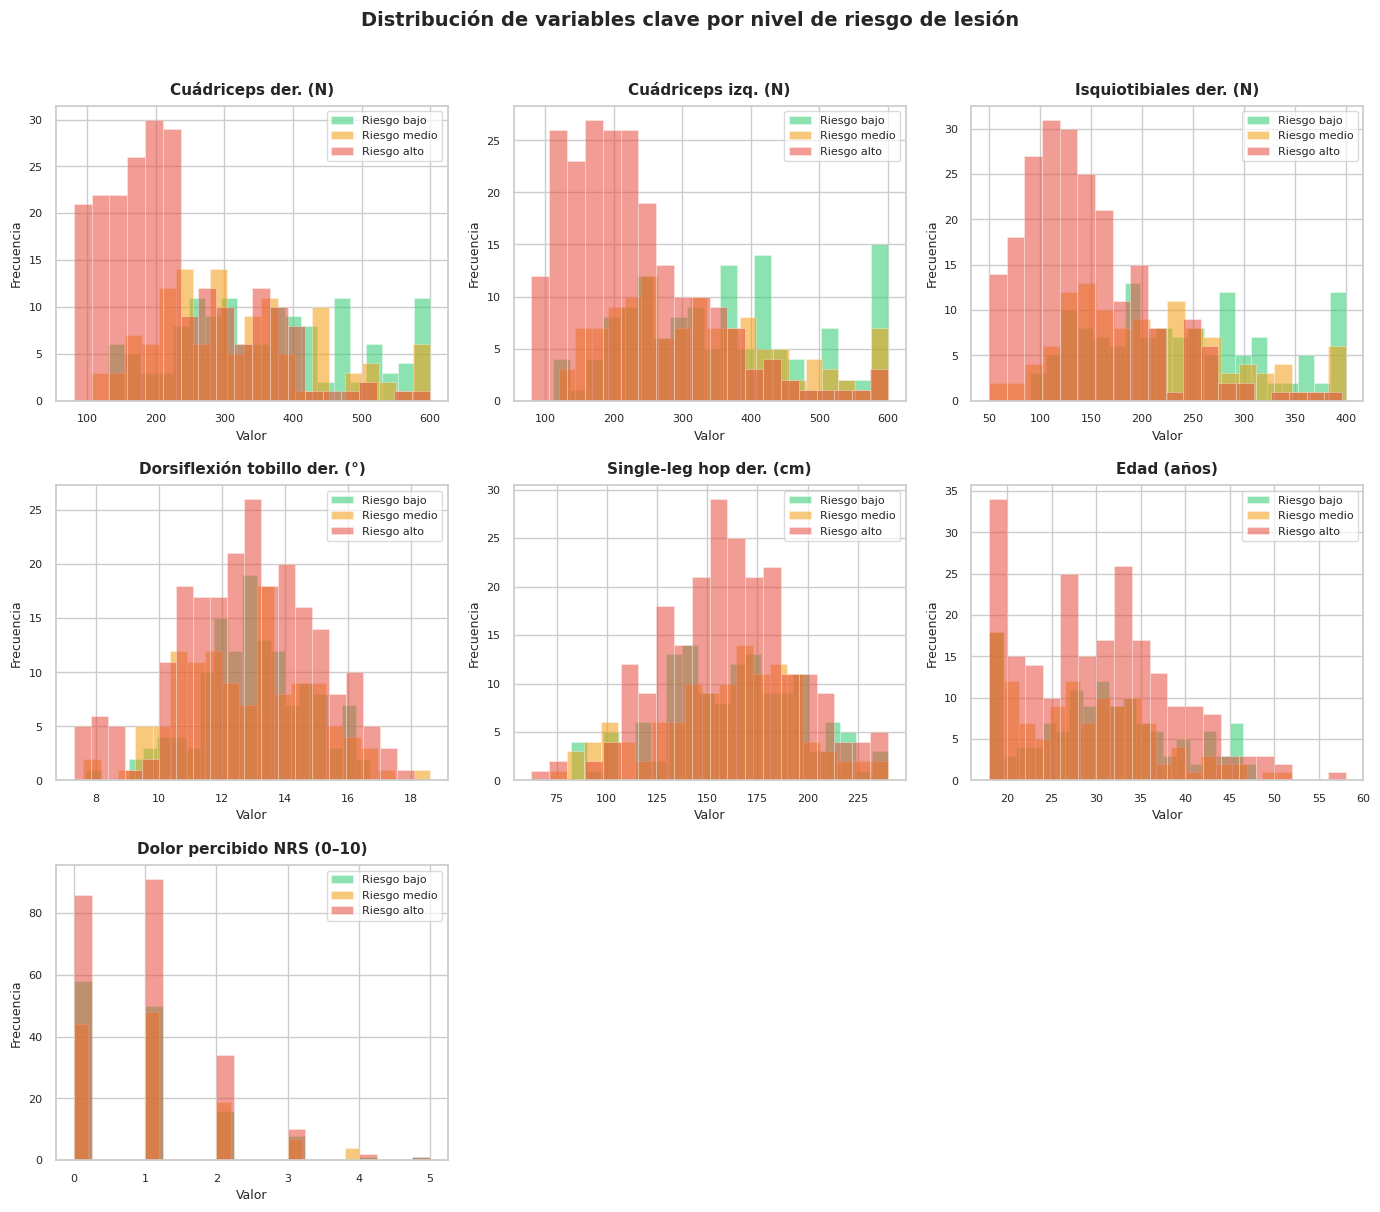

In [11]:
n_vars = len(VARIABLES_CLAVE)
n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for idx, (col, etiqueta) in enumerate(VARIABLES_CLAVE):
    ax = axes[idx]
    for nivel in ORDEN_RIESGO:
        datos_nivel = df.loc[df["riesgo_lesion"] == nivel, col].dropna()
        ax.hist(
            datos_nivel,
            bins=20,
            alpha=0.55,
            color=COLORES_RIESGO[nivel],
            label=f"Riesgo {nivel}",
            edgecolor="white",
            linewidth=0.4,
        )
    ax.set_title(etiqueta, fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Valor", fontsize=9)
    ax.set_ylabel("Frecuencia", fontsize=9)
    ax.legend(fontsize=8, framealpha=0.7)
    ax.tick_params(labelsize=8)

# Ocultar ejes sobrantes
for idx in range(n_vars, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle(
    "Distribución de variables clave por nivel de riesgo de lesión",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()

ruta_fig = FIGURAS_DIR / "histogramas_riesgo.png"
fig.savefig(ruta_fig, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {ruta_fig}")
plt.show()

---
## 4. Mapa de calor de correlaciones

Se representan las correlaciones de Pearson entre todas las variables numéricas continuas del dataset.  
Los valores cercanos a **+1** (azul oscuro) indican correlación positiva fuerte;  
los cercanos a **-1** (rojo oscuro) indican correlación negativa fuerte.

Variables incluidas en el mapa de calor: 27
Figura guardada en: /Users/__robeerr/Programacion_Local/IntApp v2/figuras/correlaciones.png


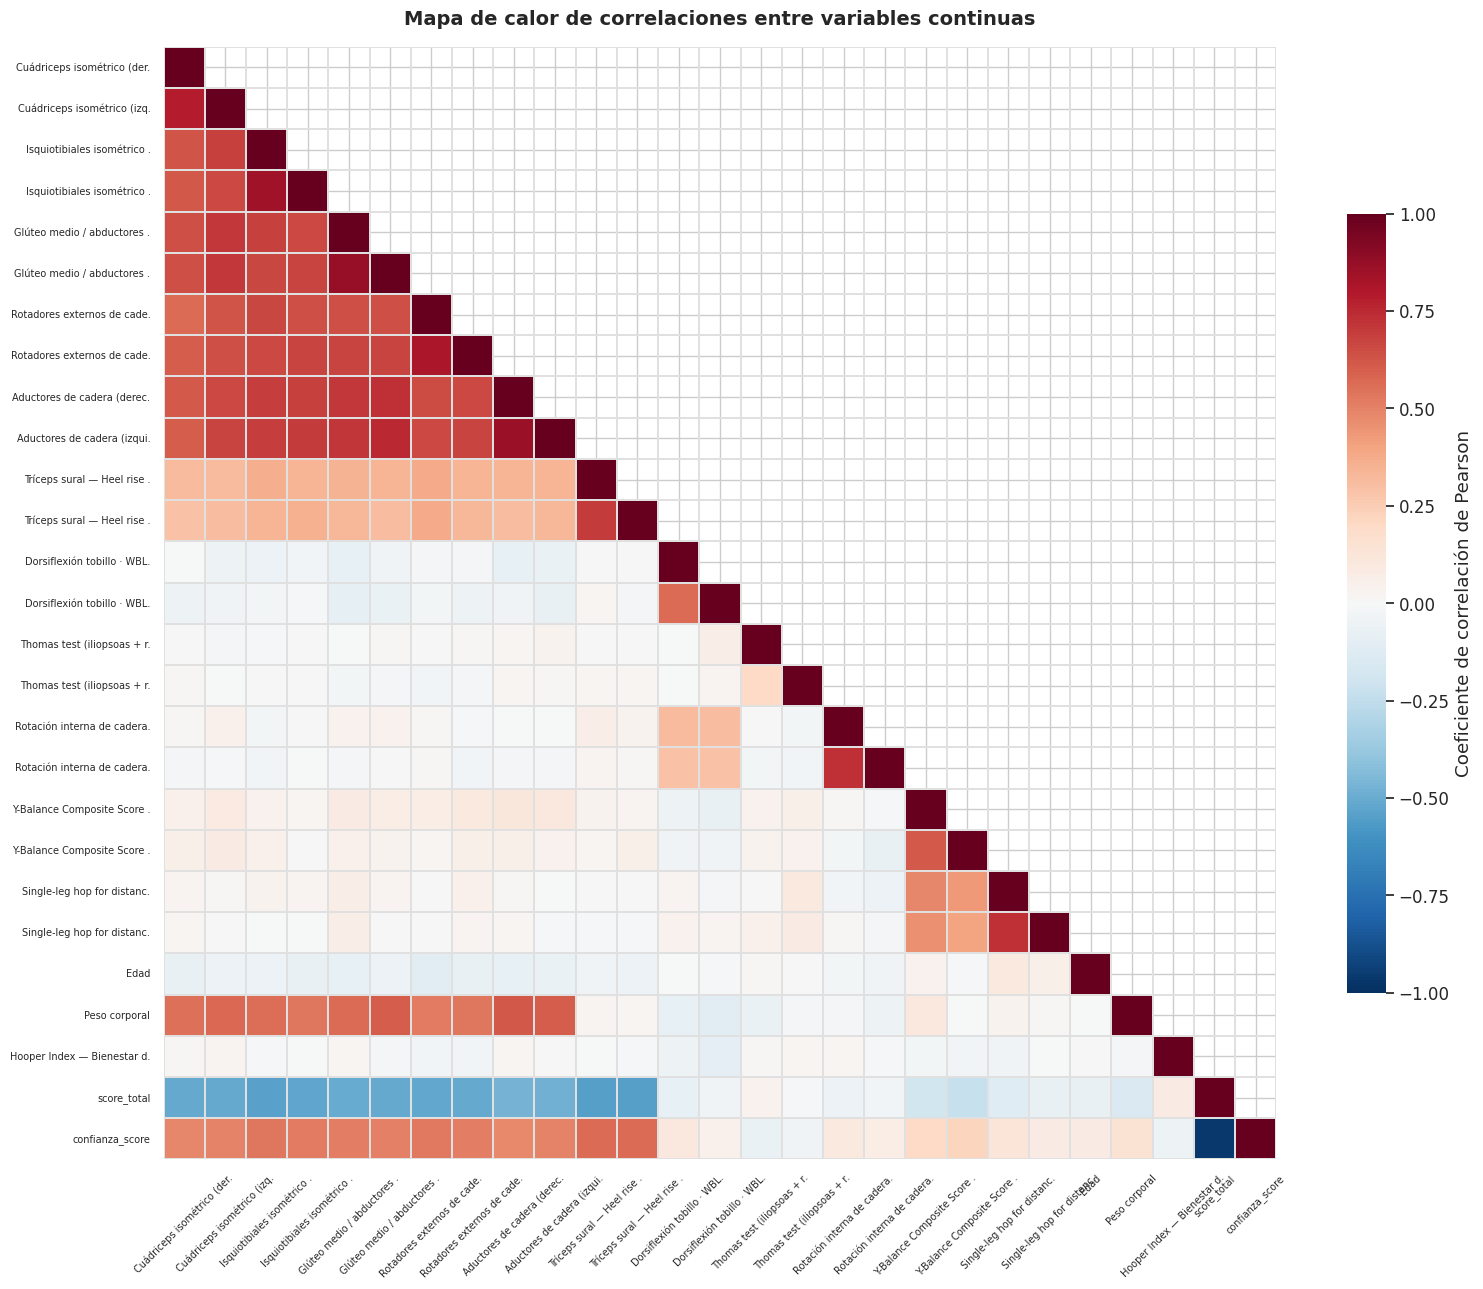

In [12]:
# Seleccionar solo columnas numéricas (excluir objetivo categórico y ordinal de baja cardinalidad)
cols_excluir = ["riesgo_lesion", "genero", "single_leg_squat_valgo_der", "single_leg_squat_valgo_izq",
                "historial_lesional", "perfil_exigencia_deportiva", "dolor_percibido_nrs"]
cols_numericas = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in cols_excluir
]

print(f"Variables incluidas en el mapa de calor: {len(cols_numericas)}")

matriz_corr = df[cols_numericas].corr(method="pearson")

# Etiquetas cortas para el heatmap
etiquetas_cortas = []
for col in cols_numericas:
    if col in VARIABLES:
        nombre = VARIABLES[col]["nombre_display"]
        # Truncar para que quepan en el eje
        if len(nombre) > 28:
            nombre = nombre[:26] + "."
        etiquetas_cortas.append(nombre)
    else:
        etiquetas_cortas.append(col)

fig, ax = plt.subplots(figsize=(16, 13))

mascara_superior = np.triu(np.ones_like(matriz_corr, dtype=bool), k=1)

sns.heatmap(
    matriz_corr,
    mask=mascara_superior,
    annot=False,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    linecolor="#e0e0e0",
    square=True,
    cbar_kws={"label": "Coeficiente de correlación de Pearson", "shrink": 0.7},
    xticklabels=etiquetas_cortas,
    yticklabels=etiquetas_cortas,
    ax=ax,
)

ax.set_title(
    "Mapa de calor de correlaciones entre variables continuas",
    fontsize=14, fontweight="bold", pad=16
)
ax.tick_params(axis="x", labelsize=7, rotation=45)
ax.tick_params(axis="y", labelsize=7, rotation=0)
plt.tight_layout()

ruta_fig = FIGURAS_DIR / "correlaciones.png"
fig.savefig(ruta_fig, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {ruta_fig}")
plt.show()

---
## 5. Comparación bilateral (boxplots)

Se comparan los valores del lado **derecho** (azul) frente al **izquierdo** (naranja)  
para las variables bilaterales más relevantes en la clínica fisioterapéutica.  
Las asimetrías entre lados son un indicador clave de riesgo de lesión.

In [13]:
# Variables bilaterales a comparar
PARES_BILATERALES = [
    ("cuadriceps",          "Cuádriceps isométrico (N)"),
    ("isquiotibiales",      "Isquiotibiales isométrico (N)"),
    ("gluteo_medio",        "Glúteo medio (N)"),
    ("dorsiflexion_tobillo","Dorsiflexión tobillo (°)"),
    ("ybalance_anterior",  "Y-Balance anterior (cm)"),
]

# Filtrar pares que realmente existen en el dataset
PARES_BILATERALES = [
    (base, etq) for base, etq in PARES_BILATERALES
    if f"{base}_der" in df.columns and f"{base}_izq" in df.columns
]
print(f"Pares bilaterales a representar: {len(PARES_BILATERALES)}")

Pares bilaterales a representar: 4


Figura guardada en: /Users/__robeerr/Programacion_Local/IntApp v2/figuras/comparacion_bilateral.png


/var/folders/m0/xlpzxvrx0810h3zj40bg28p80000gn/T/ipykernel_95554/1615177765.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/m0/xlpzxvrx0810h3zj40bg28p80000gn/T/ipykernel_95554/1615177765.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/m0/xlpzxvrx0810h3zj40bg28p80000gn/T/ipykernel_95554/1615177765.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/m0/xlpzxvrx0810h3zj40bg28p80000gn/T/ipykernel_95554/1615177765.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

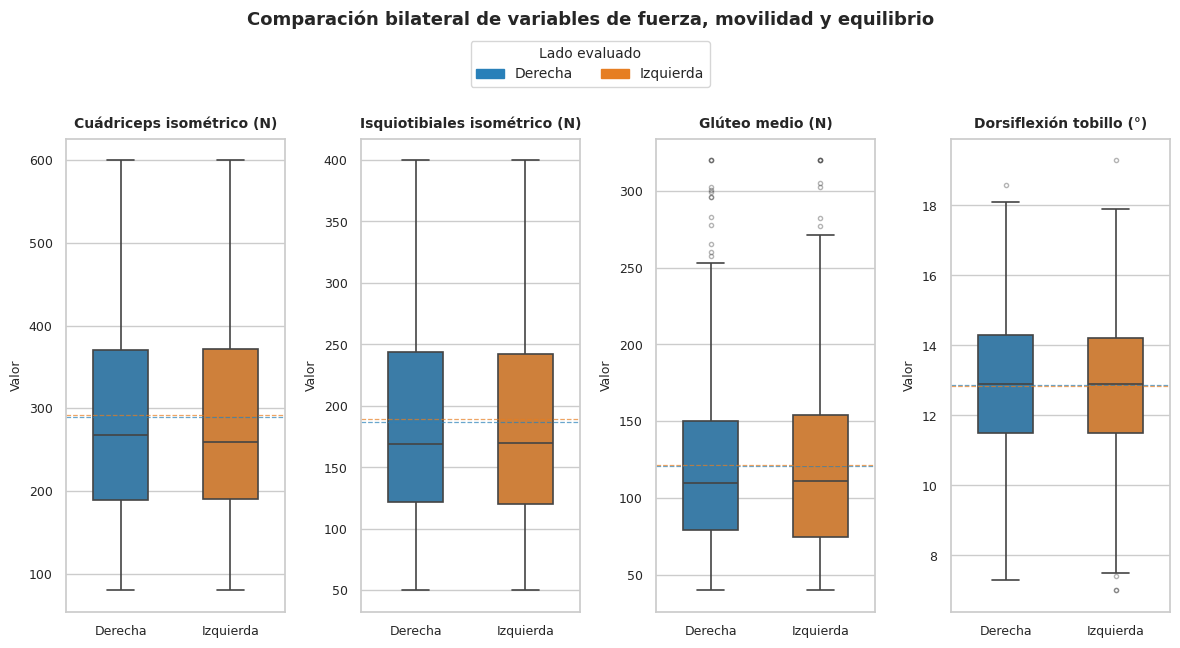

In [14]:
n_pares = len(PARES_BILATERALES)
fig, axes = plt.subplots(1, n_pares, figsize=(n_pares * 3, 6), sharey=False)

if n_pares == 1:
    axes = [axes]

COLOR_DER = "#2980b9"   # azul — derecha
COLOR_IZQ = "#e67e22"   # naranja — izquierda

for ax, (base, etiqueta) in zip(axes, PARES_BILATERALES):
    col_der = f"{base}_der"
    col_izq = f"{base}_izq"

    # Construir dataframe largo para seaborn
    datos_der = df[[col_der]].rename(columns={col_der: "valor"})
    datos_der["Lado"] = "Derecha"
    datos_izq = df[[col_izq]].rename(columns={col_izq: "valor"})
    datos_izq["Lado"] = "Izquierda"
    datos_largo = pd.concat([datos_der, datos_izq], ignore_index=True)

    sns.boxplot(
        data=datos_largo,
        x="Lado", y="valor",
        palette={"Derecha": COLOR_DER, "Izquierda": COLOR_IZQ},
        order=["Derecha", "Izquierda"],
        width=0.5,
        linewidth=1.2,
        flierprops=dict(marker="o", markersize=3, alpha=0.4),
        ax=ax,
    )

    # Calcular y mostrar medias
    media_der = df[col_der].mean()
    media_izq = df[col_izq].mean()
    ax.axhline(media_der, color=COLOR_DER, linestyle="--", linewidth=0.9, alpha=0.7)
    ax.axhline(media_izq, color=COLOR_IZQ, linestyle="--", linewidth=0.9, alpha=0.7)

    ax.set_title(etiqueta, fontsize=10, fontweight="bold", pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("Valor", fontsize=9)
    ax.tick_params(labelsize=9)

# Leyenda global
parche_der = mpatches.Patch(color=COLOR_DER, label="Derecha")
parche_izq = mpatches.Patch(color=COLOR_IZQ, label="Izquierda")
fig.legend(
    handles=[parche_der, parche_izq],
    loc="upper center", ncol=2,
    fontsize=10, framealpha=0.8,
    title="Lado evaluado", title_fontsize=10,
    bbox_to_anchor=(0.5, 1.04),
)

fig.suptitle(
    "Comparación bilateral de variables de fuerza, movilidad y equilibrio",
    fontsize=13, fontweight="bold", y=1.08
)
plt.tight_layout()

ruta_fig = FIGURAS_DIR / "comparacion_bilateral.png"
fig.savefig(ruta_fig, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {ruta_fig}")
plt.show()

---
## 6. Distribución de la variable objetivo

Se muestra cuántos deportistas hay en cada categoría de riesgo  
(**bajo**, **medio**, **alto**) tanto en número absoluto como en porcentaje.

Figura guardada en: /Users/__robeerr/Programacion_Local/IntApp v2/figuras/distribucion_riesgo.png


/var/folders/m0/xlpzxvrx0810h3zj40bg28p80000gn/T/ipykernel_95554/3763460081.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(["Bajo", "Medio", "Alto"], fontsize=11)


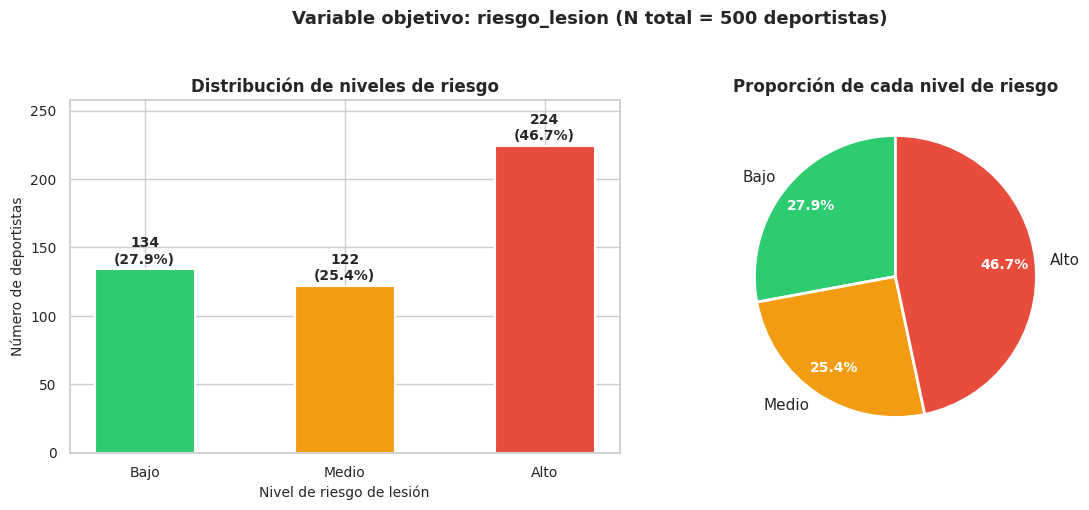

In [15]:
conteo_riesgo = df["riesgo_lesion"].value_counts().reindex(ORDEN_RIESGO)
porcentajes = conteo_riesgo / conteo_riesgo.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Gráfico de barras (izquierda) ---
ax_bar = axes[0]
barras = ax_bar.bar(
    ORDEN_RIESGO,
    conteo_riesgo.values,
    color=[COLORES_RIESGO[n] for n in ORDEN_RIESGO],
    edgecolor="white",
    linewidth=1.5,
    width=0.5,
)
for barra, n, pct in zip(barras, conteo_riesgo.values, porcentajes.values):
    ax_bar.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + max(conteo_riesgo.values) * 0.01,
        f"{n}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )
ax_bar.set_title("Distribución de niveles de riesgo", fontsize=12, fontweight="bold")
ax_bar.set_xlabel("Nivel de riesgo de lesión", fontsize=10)
ax_bar.set_ylabel("Número de deportistas", fontsize=10)
ax_bar.set_xticklabels(["Bajo", "Medio", "Alto"], fontsize=11)
ax_bar.set_ylim(0, max(conteo_riesgo.values) * 1.15)
ax_bar.tick_params(labelsize=10)

# --- Diagrama de sectores (derecha) ---
ax_pie = axes[1]
wedges, texts, autotexts = ax_pie.pie(
    conteo_riesgo.values,
    labels=["Bajo", "Medio", "Alto"],
    autopct="%1.1f%%",
    colors=[COLORES_RIESGO[n] for n in ORDEN_RIESGO],
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    pctdistance=0.78,
)
for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight("bold")
    autotext.set_color("white")
ax_pie.set_title("Proporción de cada nivel de riesgo", fontsize=12, fontweight="bold")

fig.suptitle(
    f"Variable objetivo: riesgo_lesion (N total = {len(df)} deportistas)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()

ruta_fig = FIGURAS_DIR / "distribucion_riesgo.png"
fig.savefig(ruta_fig, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {ruta_fig}")
plt.show()

---
## 7. Resumen

El análisis exploratorio ha generado las siguientes figuras:

| Archivo | Contenido |
|---|---|
| `histogramas_riesgo.png` | Distribución de 9 variables clave coloreadas por nivel de riesgo |
| `correlaciones.png` | Mapa de calor de correlaciones de Pearson entre variables continuas |
| `comparacion_bilateral.png` | Boxplots comparativos derecha vs. izquierda para variables bilaterales |
| `distribucion_riesgo.png` | Diagrama de barras y sectores de la variable objetivo |

**Estas figuras están listas para incluir en tu TFM. Las encontrarás en la carpeta `figuras/`**

---

### Observaciones clave a destacar en el TFM

- **Histogramas**: observa si las distribuciones de los grupos de riesgo se solapan o se separan claramente. Una buena separación indica que la variable tiene poder discriminante.
- **Correlaciones**: las variables del mismo bloque (p. ej., cuádriceps derecho e izquierdo) suelen estar muy correlacionadas entre sí. Variables de bloques distintos con alta correlación pueden indicar relaciones clínicas interesantes.
- **Comparación bilateral**: asimetrías entre lados (der vs. izq) por encima del 10–15 % son clínicamente relevantes y se asocian a mayor riesgo de lesión según la literatura.
- **Variable objetivo**: si la distribución está muy desequilibrada (p. ej., 70 % bajo riesgo), habrá que aplicar técnicas de balanceo de clases (SMOTE, pesos de clase) en el paso de modelado.

El siguiente paso es el **preprocesado y preparación de datos** (`03_preprocesado.ipynb`).